<a href="https://colab.research.google.com/github/fsantibanezleal/dirichlet/blob/master/ProjHyperPaperDB01VizCropped.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic operations with HDF5 Data

This is a notebook for loading and visualizate H5 files from our HSI scanlines cameras.

The code for this notebook is available here (in preparation)
https://github.com/fsantibanezleal

It can be run on Colab at this URL (in preparation)
https://colab.research.google.com/github/fsantibanez/XXX/ProjHSIPipeline01LoadandVisualizationHDF5.ipynb

### Environment Setup 

First, obtain access to our internal data.


## Define if you have full access to all data and HSI codes or if you require sample_data and sample_code

If you have your data in Drive and you have the HSI code in the sample places with the spececif paths, then keep this variable as True, otherwise set the variable to False.

If the variable if False, a sample_data will be cloned from git repository

In [1]:
boolaccesstodrive = True

if boolaccesstodrive:
  from google.colab import drive
  drive.mount('/content/drive')
else:
  # Implement when demo is available at Github
  dummy = 1

Mounted at /content/drive


## Define parameters for the analysis

if required

# Define relevant paths

The location of the H5 data must be defined in the drive

The code for the HSI-ALGES code must be append to the path in order to faccilitates its use

In [3]:
if boolaccesstodrive:
  gencodeFolder = './drive/MyDrive/ColabDATA/0_Codes/'
  hsicodeFolder = './drive/MyDrive/ColabDATA/0_Codes/HSIALGESCODE/'
  
  hsidataFolder = './drive/MyDrive/ColabDATA/HyperPaperDB2021/samples_innovaxion_pelambres/samples/'
  #hsidataFolder = './drive/MyDrive/ColabDATA/HyperPaperDB2021/samples_cjara_minhales/samples/'
  #hsidataFolder = './drive/MyDrive/ColabDATA/HyperPaperDB2021/samples_alges_quimiometria/samples/'
else:
  gencodeFolder = './0_Codes/'
  hsicodeFolder = './0_Codes/hsi_code/'
  
  hsidataFolder = './sample_data/'
  

# Install required packages

spectral hdf5 and so on
(pyserial is installed only to avoid warnings of missing dependencies)

##in progress:
I think yadlt is not required anymore 

In [4]:
!pip install spectral  common_utils 

     |████████████████████████████████| 184kB 5.4MB/s 
  Created wheel for spectral: filename=spectral-0.22.2-cp37-none-any.whl size=212938 sha256=b963b103350b0359a42f3ffba5bfe757562408f3e4b5177ae1c1a7de178fe2df
  Stored in directory: /root/.cache/pip/wheels/fb/00/da/ac778d1ab6e196cb7f56d104d4dfdfc0aad4e2b208275c0726
Successfully built spectral


In [5]:
# CHeck if required
# !pip install tqdm yadlt PyQt5 pyserial GPflow ipywidgets
# !jupyter nbextension enable --py widgetsnbextension

     |████████████████████████████████| 41.0MB 101kB/s 



## Imports and utility functions

We need numpy, and some utilities for visualizing the data.

In [22]:
# System libs
import sys, os, csv, torch, scipy.io, PIL.Image, torchvision.transforms

from glob import glob

import numpy as np
import scipy.io as io
import scipy.linalg as linalg
from scipy import sparse
import time
import numpy.testing as npt

import pytest

import matplotlib.pyplot as plt 

from bokeh.plotting import figure, output_file, show
from bokeh.io import output_notebook
from bokeh.models import ColumnDataSource, ranges, LabelSet

from bokeh.plotting import reset_output
from sklearn.metrics import confusion_matrix


# Our libs
# Provide acces to the hsi code
sys.path.append(gencodeFolder)
sys.path.append(hsicodeFolder + 'src/python')

from hsi.datafiles import H5PyContainer, HyperspectralImageDataFile
from hsi.datafiles.formatters import AsdFormatter, Hdf5Formatter

from hsi.datafiles import H5PyContainer, HyperspectralImageDataFile
from hsi.modules.features.spectral.pls import PLSFeature
from hsi.modules.features.spectral.spectrum import SpectrumFeature
from hsi.modules.machine_learning.classification import *

from hsi.modules.clustering import *


In [8]:
def LoadDataSet(pathFile):
  dataImage = HyperspectralImageDataFile()
  dataImage.load_data(pathFile, container=H5PyContainer())
  return dataImage   

def visualize_result(img):
  # aggregate images and save
  #im_vis = numpy.concatenate((img, pred_color), axis=1)
  #display(PIL.Image.fromarray(im_vis))
  # display(PIL.Image.fromarray(img))
  img8 = 255 * img / np.max(np.ravel(img))
  PIL_image = PIL.Image.fromarray(np.uint8(img8)).convert('RGB')
  display(PIL_image)

def show_img_rawbandcolor_controlled(av_data, av_fname, idx_data, idx_fname, idx_R, idx_G, idx_B):
  # Load selected dataset
  dataSet = LoadDataSet(av_data[idx_data] + av_fname[idx_fname])
  cubehsi = dataSet.get_cube()
  # dimensiones of the cube
  dimshsi = dataSet.get_cube_shape()
  
  # Transpose spatial dimensions
  imghsi = np.zeros((dimshsi[1],dimshsi[0],3))
  
  imghsi[:,:,0] = np.transpose(cubehsi[:,:,idx_R])
  imghsi[:,:,1] = np.transpose(cubehsi[:,:,idx_G])
  imghsi[:,:,2] = np.transpose(cubehsi[:,:,idx_B])

  visualize_result(imghsi)

selecteddatafolder = 'None'
selecteddatafilenm = 'None'
selectedhsicube = None
def show_img_rawcolor_global(av_data, av_fname, idx_data, idx_fname, idx_R, idx_G, idx_B):
  global selecteddatafolder
  global selecteddatafilenm
  global selectedhsicube
  if (selecteddatafolder != av_data[idx_data]) or (selecteddatafilenm != av_fname[idx_data]):
    selecteddatafolder = av_data[idx_data]
    selecteddatafilenm = av_fname[idx_fname]
    # Load selected dataset
    dataSet = LoadDataSet(av_data[idx_data] + av_fname[idx_data])
    selectedhsicube = dataSet.get_cube()
      
  # dimensiones of the cube
  dimshsi = selectedhsicube.shape
  
  # Transpose spatial dimensions
  imghsi = np.zeros((dimshsi[1],dimshsi[0],3))
  
  imghsi[:,:,0] = np.transpose(selectedhsicube[:,:,idx_R])
  imghsi[:,:,1] = np.transpose(selectedhsicube[:,:,idx_G])
  imghsi[:,:,2] = np.transpose(selectedhsicube[:,:,idx_B])

  visualize_result(imghsi)


# List of available data

The structure provided by the HSI acquisition system is the following:

folderhsisample 
- configurations
- datafiles
  - SWIR3withNI.h5
  - SWIR3withNI.json
  - SWIR3withNI_darkref.h5
  - SWIR3withNI_darkref.json
  - SpectralCamerasCMOS-NC.h5
  - SpectralCamerasCMOS-NC.json
  - SpectralCamerasCMOS-NC_darkref.h5
  - SpectralCamerasCMOS-NC_darkref.json

In [9]:
from os import listdir
 
def list_files(directory, extension):
    return [f for f in listdir(directory) if f.endswith('.' + extension)]

# Find available datasets

In [10]:
available_data = list_files(hsidataFolder,'h5')
available_data = list(np.sort(np.array((available_data))))
available_data

['base_01_v1.h5',
 'base_01_v2.h5',
 'base_02_v1.h5',
 'base_02_v2.h5',
 'base_03_v1.h5',
 'base_03_v2.h5',
 'base_04_v1.h5',
 'base_04_v2.h5',
 'base_05_v1.h5',
 'base_05_v2.h5',
 'base_06_v1.h5',
 'base_06_v2.h5',
 'base_07_v1.h5',
 'base_07_v2.h5',
 'base_08_v1.h5',
 'base_08_v2.h5',
 'base_09_v1.h5',
 'base_09_v2.h5',
 'base_10_v1.h5',
 'base_10_v2.h5',
 'base_11_v1.h5',
 'base_11_v2.h5',
 'base_12_v1.h5',
 'base_12_v2.h5',
 'base_13_v1.h5',
 'base_13_v2.h5',
 'base_14_v1.h5',
 'base_14_v2.h5',
 'base_15_v1.h5',
 'base_15_v2.h5',
 'base_16_v1.h5',
 'base_16_v2.h5',
 'base_17_v1.h5',
 'base_17_v2.h5',
 'base_18_v1.h5',
 'base_18_v2.h5',
 'base_19_v1.h5',
 'base_19_v2.h5',
 'base_20_v1.h5',
 'base_20_v2.h5',
 'base_21_v1.h5',
 'base_21_v2.h5',
 'base_22_v1.h5',
 'base_22_v2.h5',
 'base_24_v1.h5',
 'base_24_v2.h5',
 'base_25_v1.h5',
 'base_25_v2.h5',
 'base_26_v1.h5',
 'base_26_v2.h5',
 'fino_01_v1.h5',
 'fino_01_v2.h5',
 'fino_02_v1.h5',
 'fino_02_v2.h5',
 'fino_03_v1.h5',
 'fino_03_

In [11]:
labnames = available_data
avfnames = available_data

# Interactive visualization of the HDF5 files

In [12]:
#from collections import Counter
from pylab import savefig
import itertools

import ipywidgets as widgets
from ipywidgets import interact, fixed, interact_manual, HBox, Layout,VBox
from IPython.display import clear_output
from scipy import interpolate


In [13]:
%%html
<style>
    .widget-select > select {text-color: white;}   
    .widget-label > label {text-color: white;}
</style>

In [30]:
dpFiles = widgets.Dropdown(layout={'width': 'initial'},options = list(zip(labnames, avfnames)))

dpr = widgets.IntSlider(min=0, max=200, step=1, value=176)
dpg = widgets.IntSlider(min=0, max=200, step=1, value=160)
dpb = widgets.IntSlider(min=0, max=200, step=1, value=61)


cbinitshow = widgets.Checkbox(description="Show!")

selecteddatafilenm = 'None'
dataSet = None
selectedhsicube = None

style = {'description_width': 'initial'}
layout = {'text-color': 'white'}

updatinggui = False
firstiteration = True
def show_img_rawcolor_global_interact(selfname, cboxf, idxR, idxG, idxB):
  global selecteddatafilenm
  global selectedhsicube
  global dataSet

  global dpr
  global dpg
  global dpb

  global updatinggui

  global ifuse
  
  if selecteddatafilenm != selfname:

    updatinggui = True
    selecteddatafilenm = selfname
    # Load selected dataset
    dataSet = LoadDataSet(hsidataFolder + selecteddatafilenm)
    selectedhsicube = dataSet.get_cube()
    
    # dimensiones of the cube
    dimshsi = selectedhsicube.shape
    
    # Fix range wavelengts
    ifuse.children[2].value = 0
    ifuse.children[3].value = 0
    ifuse.children[4].value = 0


    ifuse.children[2].max = dimshsi[2]-1
    ifuse.children[3].max = dimshsi[2]-1
    ifuse.children[4].max = dimshsi[2]-1

    ifuse.children[2].value = int(dimshsi[2]/2)
    ifuse.children[3].value = int(dimshsi[2]/2)
    ifuse.children[4].value = int(dimshsi[2]/2)

    idxR = int(dimshsi[2]/2)
    idxG = int(dimshsi[2]/2)
    idxB = int(dimshsi[2]/2)

    updatinggui = False

  if not updatinggui:
    # dimensiones of the cube
    dimshsi = selectedhsicube.shape


    # Transpose spatial dimensions
    imghsi = np.zeros((dimshsi[1],dimshsi[0],3))
  
    imghsi[:,:,0] = np.transpose(selectedhsicube[:,:,idxR])
    imghsi[:,:,1] = np.transpose(selectedhsicube[:,:,idxG])
    imghsi[:,:,2] = np.transpose(selectedhsicube[:,:,idxB])

    if not ifuse.children[1].value:
      ifuse.children[-1].clear_output()
    else:
      visualize_result(imghsi)

ifuse = widgets.interactive(show_img_rawcolor_global_interact,
                        selfname = dpFiles, 
                        cboxf = cbinitshow,
                        idxR = dpr, 
                        idxG = dpg, 
                        idxB = dpb,
                        layout = layout,style=style)

controlsFiles = HBox(ifuse.children[0:2], layout = Layout(flex_flow='row wrap'))
controlsColor = HBox(ifuse.children[2:-1], layout = Layout(flex_flow='row wrap'))
output = ifuse.children[-1]
display(VBox([controlsFiles, controlsColor, output]))


In [15]:
selectedhsicube.shape

(77, 62, 1210)

In [16]:
281*301

84581

# Visualization of spectra for datafile

In [31]:
myfoontsize = 25
mylinewidth = 3

import matplotlib.pylab as pylab
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (20, 10),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
pylab.rcParams.update(params)

dpFS = widgets.Dropdown(layout={'width': 'initial'},options = list(zip(labnames, avfnames)))


listnumspectra = (10, 100, 500, 1000)
listlabspectra = ('10', '100', '500', '1000')
dpnums = widgets.Dropdown(
    layout={'width': 'initial'},
    options = list(zip(listlabspectra, listnumspectra)))


cbinitSpec = widgets.Checkbox(description="Show!")
cbupdateSpec = widgets.Checkbox(description="Update!")

selecteddatafileSpec = 'None'
selectedhsicube = None
selectedwl = None
dataSet = None

style = {'description_width': 'initial'}
layout = {'text-color': 'white'}

updatinggui = False
firstiteration = True
def show_spectra_global_interact(selfname, cbox, numspec, cupd):
  global selecteddatafileSpec
  global selectedhsicube
  global selectedwl
  global dataSet

  global i
  
  if selecteddatafileSpec != selfname:
    i.children[-1].clear_output()

    selecteddatafileSpec = selfname
    # Load selected dataset
    dataSet = LoadDataSet(hsidataFolder + selecteddatafileSpec)
    selectedhsicube = dataSet.get_cube()
    selectedwl = dataSet.get_wavelength()

  # dimensiones of the cube
  dimshsi = selectedhsicube.shape

  # 1D spectra 
  dummySpectra = np.reshape(selectedhsicube,(dimshsi[0]*dimshsi[1],dimshsi[2]))

  # Select random number of spectra as required
  numSpectra = dummySpectra.shape[0]
  numspectratoshow = min(numspec,numSpectra)

  idxselectedSpectra = np.random.choice(numSpectra, numspectratoshow)
  selectedspectra = dummySpectra[idxselectedSpectra,:]

  if not i.children[1].value:
    i.children[-1].clear_output()
  else:
    figO, ax = plt.subplots(figsize=(20,10))

    plt.plot(selectedwl, np.transpose(selectedspectra), label='Spectra for Sample', linewidth = mylinewidth)

    plt.title(str(numspectratoshow) + ' Reflectance Spectra for Sample : ' + selecteddatafileSpec[:-3] ,fontsize=myfoontsize+3)
    #plt.legend(fontsize=myfoontsize+3)
    plt.xlabel('Wavelength (nm)',fontsize=myfoontsize+3)
    plt.ylabel('Reflectance',fontsize=myfoontsize+3)
    plt.ylim(0, 30000) #65000

    for tick in ax.xaxis.get_major_ticks():
        tick.label.set_fontsize(myfoontsize)         
    for tick in ax.yaxis.get_major_ticks():
        tick.label.set_fontsize(myfoontsize) 
        
        
    plt.show()


i = widgets.interactive(show_spectra_global_interact, 
                        selfname = dpFS, 
                        cbox = cbinitSpec,
                        numspec = dpnums, 
                        cupd = cbupdateSpec,
                        layout = layout,style=style)

controlsData = HBox(i.children[0:2], layout = Layout(flex_flow='row wrap'))
controlsOpts = HBox(i.children[2:-1], layout = Layout(flex_flow='row wrap'))
outputSpec = i.children[-1]
#display(i)
display(VBox([controlsData, controlsOpts, outputSpec]))

In [ ]:
dimshsi

(1463, 384, 288)

In [19]:
selectedwl

array([   0,    1,    2, ..., 1207, 1208, 1209])

In [20]:
selectedhsicube.shape

(69, 163, 1210)

In [40]:
#param m: Spatial cohesion of each segment.
#param k: Number of minimum desired segments. The number is likely to increase.
#param hsi: True if input is an hyperspectral image
#param scale: True if data position is to be scaled to a uniform grid in 2D-3D space

h = HSLIC(m=1,
          k=20,
          hsi=True,
          scale=False)

segments = h.run(dataSet.get_point_cloud(), iterations=2)


In [43]:
np.histogram(segments,np.unique(segments))

(array([2535, 2780, 2534, 3136]), array([ 0,  6, 12, 18, 24]))

In [47]:
np.unique(segments)

array([ 0,  6, 12, 18, 24])

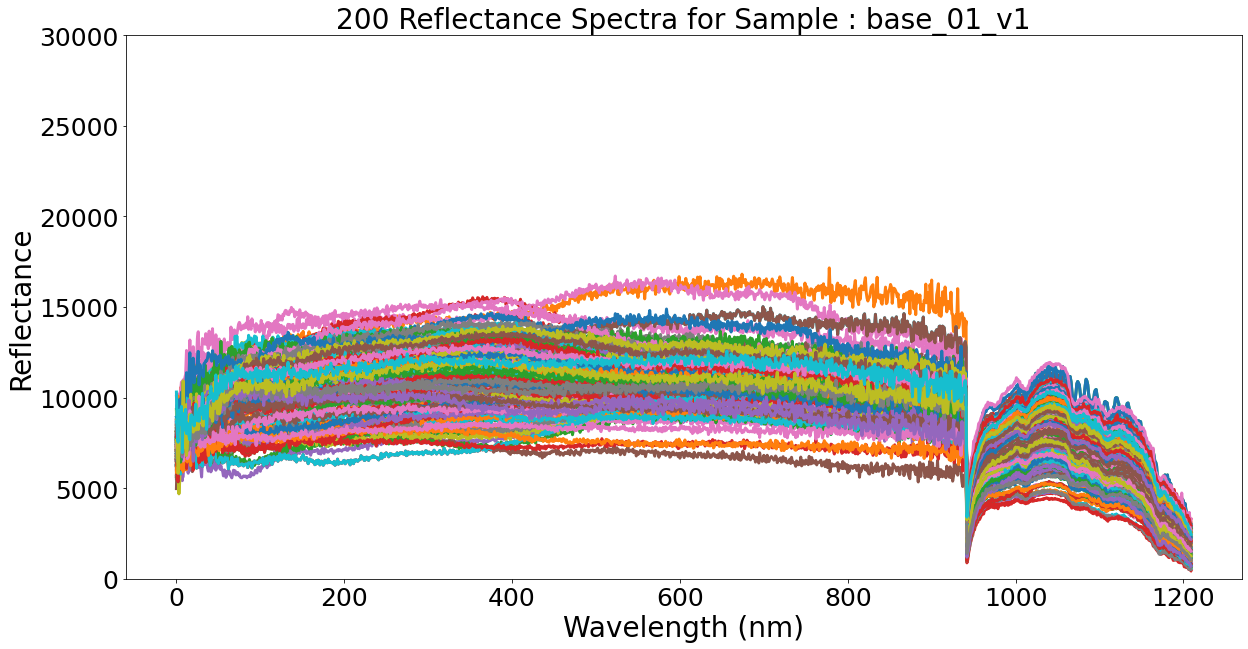

In [49]:
idclusters = np.unique(segments)

# dimensiones of the cube
dimshsi = selectedhsicube.shape

# 1D spectra 
dummySpectra = np.reshape(selectedhsicube,(dimshsi[0]*dimshsi[1],dimshsi[2]))

dummySpectra = dummySpectra[segments == idclusters[4],:]

numspec = 200
# Select random number of spectra as required
numSpectra = dummySpectra.shape[0]
numspectratoshow = min(numspec,numSpectra)

idxselectedSpectra = np.random.choice(numSpectra, numspectratoshow)
selectedspectra = dummySpectra[idxselectedSpectra,:]

if not i.children[1].value:
  i.children[-1].clear_output()
else:
  figO, ax = plt.subplots(figsize=(20,10))

  plt.plot(selectedwl, np.transpose(selectedspectra), label='Spectra for Sample', linewidth = mylinewidth)

  plt.title(str(numspectratoshow) + ' Reflectance Spectra for Sample : ' + selecteddatafileSpec[:-3] ,fontsize=myfoontsize+3)
  #plt.legend(fontsize=myfoontsize+3)
  plt.xlabel('Wavelength (nm)',fontsize=myfoontsize+3)
  plt.ylabel('Reflectance',fontsize=myfoontsize+3)
  plt.ylim(0, 30000) #65000

  for tick in ax.xaxis.get_major_ticks():
      tick.label.set_fontsize(myfoontsize)         
  for tick in ax.yaxis.get_major_ticks():
      tick.label.set_fontsize(myfoontsize) 
